In [1]:
import sys
sys.path.append("..")
import os
import pandas as pd
from tqdm import tqdm
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "truth_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [3]:
results_dir = f"/hdd/ivny/direct_qa_in_domain_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

def extract_signal_mean(signal_str):
    # signal_str format: "mu=0.123, sigma=0.456"
    match = re.search(r"mu=([0-9.]+)", signal_str)
    if match:
        return float(match.group(1))
    else:
        return None

signal_means = []
lc_means = []

original_response = []
calibrated_response = []

for leaf_dir in leaf_dirs:
    _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
    if os.path.exists(os.path.join(leaf_dir, "calibration_details.csv")):
        csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_details.csv"), index_col=0)
        
        original_response += csv_data["original_response"].tolist()
        calibrated_response += csv_data["calibrated_tp_rewritten_response"].tolist()
        
        original_response += csv_data["original_response"].tolist()
        calibrated_response += csv_data["calibrated_lc_rewritten_response"].tolist()
        
        original_response += csv_data["original_response"].tolist()
        calibrated_response += csv_data["calibrated_su_rewritten_response"].tolist()
        
        signal_means += csv_data["calibrated_lc"].apply(extract_signal_mean).tolist()
        lc_means += csv_data["calibrated_lc_rewritten_lc"].apply(extract_signal_mean).tolist()
        
        signal_means += csv_data["calibrated_tp"].apply(extract_signal_mean).tolist()
        lc_means += csv_data["calibrated_tp_rewritten_lc"].apply(extract_signal_mean).tolist()

        signal_means += csv_data["calibrated_su"].apply(extract_signal_mean).tolist()
        lc_means += csv_data["calibrated_su_rewritten_lc"].apply(extract_signal_mean).tolist()

    else:
        print(dataset_name, model_name, "calibration_details.csv not found")


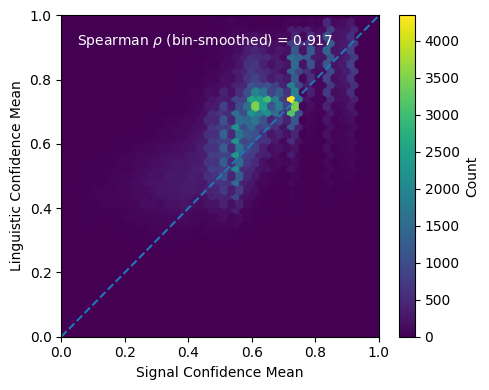

In [4]:
x = np.asarray(signal_means, dtype=float)
y = np.asarray(lc_means, dtype=float)

n = min(len(x), len(y))
x = x[:n]
y = y[:n]

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

def spearman_with_binning(x, y, n_bins=20, agg='mean'):
    df = pd.DataFrame({'x': x, 'y': y})

    # Create quantile-based bins
    df['bin'] = pd.qcut(df['x'], q=n_bins, duplicates='drop')

    # Aggregate within bins
    if agg == 'mean':
        grouped = df.groupby('bin', observed=True).mean(numeric_only=True)
    elif agg == 'median':
        grouped = df.groupby('bin', observed=True).median(numeric_only=True)
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # Compute Spearman on aggregated points
    rho, p = spearmanr(grouped['x'], grouped['y'])

    return rho, p, grouped

# usage
rho, p, grouped = spearman_with_binning(x, y, n_bins=100000)

# rho = spearmanr(x, y)[0]

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

hb = ax.hexbin(
    x,
    y,
    gridsize=40,
    extent=(0,1,0,1),
)

ax.plot([0,1],[0,1], linestyle='--')
ax.set_xlabel("Signal Confidence Mean")
ax.set_ylabel("Linguistic Confidence Mean")
ax.set_xlim(0,1)
ax.set_ylim(0,1)

ax.text(
    0.05, 0.95,
    rf"Spearman $\rho$ (bin-smoothed) = {rho:.3f}",
    transform=ax.transAxes,
    verticalalignment='top',
    color='white',
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Count")

plt.tight_layout()
# plt.savefig("signal_linguistic_confidence_alignment.pdf", dpi=300, bbox_inches='tight')
plt.show()

/mnt/hdd_1/home/ivan/miniconda3/envs/llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 2005/2005 [07:40<00:00,  4.36it/s]


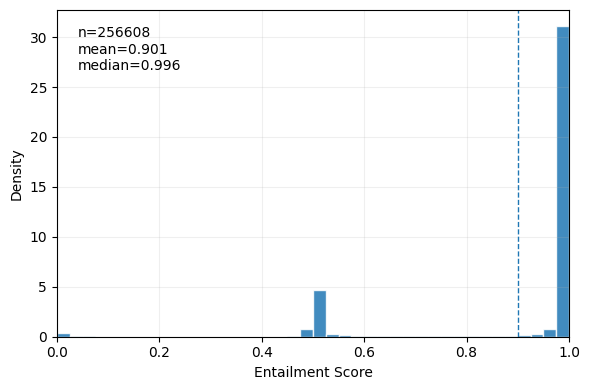

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
from scipy.stats import gaussian_kde

# ---- Environment stability (keep yours) ----
os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torchinductor_cache"
os.environ["TRITON_CACHE_DIR"] = "/tmp/triton_cache"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HOME"] = "/tmp/huggingface"
os.environ["HUGGINGFACE_HUB_CACHE"] = "/tmp/huggingface/hub"

from sentence_transformers import CrossEncoder

# ---- Your data ----
list1 = original_response   # original (x1)
list2 = calibrated_response  # rewritten (x2)

# # ---- Sample at most 5000 pairs ----
# max_samples = 5000
# if len(list1) > max_samples:
#     rng = np.random.default_rng(42)
#     indices = rng.choice(len(list1), size=max_samples, replace=False)
#     list1 = [list1[i] for i in indices]
#     list2 = [list2[i] for i in indices]

# ---- Load NLI model (DeBERTa) ----
model = CrossEncoder("cross-encoder/nli-deberta-v3-base")

# ---- Direction: rewrite -> original ----
pairs_21 = [(str(x2), str(x1)) for x1, x2 in zip(list1, list2)]


logits_21 = model.predict(
    pairs_21,
    batch_size=128,
    show_progress_bar=True,
)

probs_21 = sp.softmax(logits_21, axis=1)

# NLI label order: [contradiction, entailment, neutral]
entail_21 = probs_21[:, 1]
neutral_21 = probs_21[:, 2]

# ---- Soft entailment (lenient) ----
similarities = entail_21 + 0.5 * neutral_21

# ---- Plot (same style as yours) ----
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
bins = np.linspace(0.0, 1.0, 41)

ax.hist(similarities, bins=bins, density=True, alpha=0.85, edgecolor="white")
ax.axvline(np.mean(similarities), linestyle="--", linewidth=1)


# ax.set_title("Calibrated Response Entailment (DeBERTa NLI)")
ax.set_xlabel("Entailment Score")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.grid(alpha=0.2)

ax.text(
    0.04,
    0.95,
    f"n={len(similarities)}\nmean={np.mean(similarities):.3f}\nmedian={np.median(similarities):.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
)

plt.tight_layout()
# plt.savefig("calibrated_response_entailment_scores.pdf", dpi=300, bbox_inches="tight")
plt.show()

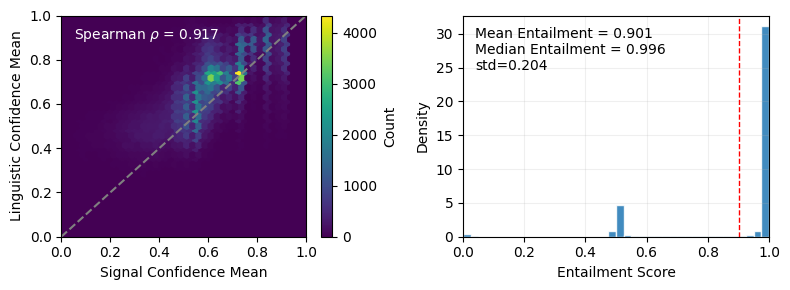

In [6]:
# Combined figure: calibration alignment (left) + entailment quality (right)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# ---- Left: hexbin signal vs linguistic confidence ----
ax0 = axes[0]
hb = ax0.hexbin(
    x,
    y,
    gridsize=40,
    extent=(0, 1, 0, 1),
)
ax0.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax0.set_xlabel("Signal Confidence Mean")
ax0.set_ylabel("Linguistic Confidence Mean")
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
ax0.text(
    0.05,
    0.95,
    fr"Spearman $\rho$ = {rho:.3f}",
    transform=ax0.transAxes,
    va="top",
    color="white",
)
cb = fig.colorbar(hb, ax=ax0)
cb.set_label("Count")

# ---- Right: entailment score distribution with smooth KDE ----
ax1 = axes[1]
bins = np.linspace(0.0, 1.0, 41)
ax1.hist(similarities, bins=bins, density=True, alpha=0.85, edgecolor="white")

ax1.axvline(np.mean(similarities), linestyle="--", linewidth=1, color="red")
ax1.set_xlabel("Entailment Score")
ax1.set_ylabel("Density")
ax1.set_xlim(0, 1)
ax1.grid(alpha=0.2)
ax1.text(
    0.04,
    0.95,
    f"Mean Entailment = {np.mean(similarities):.3f}\nMedian Entailment = {np.median(similarities):.3f}\nstd={np.std(similarities):.3f}",
    transform=ax1.transAxes,
    va="top",
    ha="left",
)

plt.tight_layout()
plt.savefig("direct_qa_linguistic-calibration-quality.pdf", dpi=300, bbox_inches="tight")
plt.show()